<h1> ​Evolutionary Algorithms </h1>

In Optimization: We usually don't want to find a path.

Rather: We want to find the best possible solution in a very large space.

**Applications:**

1. Engineering design</br>
2. Scheduling</br>
3. Feature selection in ML</br>
4. Hyperparameter tuning</br>
5. Neural network design</br>

Where the function may:</br>
1. be non-linear.</br>
2. have multiple peaks.</br>
3. not differentiable.

The idea of ​​Evolutionary Algorithms

Inspired by natural evolution:

Darwin:

Individuals</br>
|</br>
|</br>
Variation</br>
|</br>
|</br>
Selection</br>
|</br>
|</br>
Better Generation

That is:</br>
The new generation usually becomes better than the previous generation.

Step 1 — Representation (Encoding) </br>
Step 2 — Fitness Function</br>
Step 3 — Selection (Roulette Wheel Selection, Tournament Selection)</br>
Step 4 — Crossover</br>
Step 5 — Mutation (Premature Convergence) (Diversity) </br>
Step 6 — Elitism

In [24]:
import matplotlib.pyplot as plt

from problems.knapsack import (
    KnapsackProblem,
    create_random_knapsack
)
from src.GA import (
    initialize_population,
    evaluate_population,
    tournament_selection,
    elitism,
    roulette_selection,
    single_point_crossover,
    mutation,
    genetic_algorithm,
)


<h3> Step 1: Defining the problem </h3>

In [2]:
weights = [
    5,
    3,
    7,
    2,
    6,
]

values = [
    10,
    8,
    14,
    5,
    12,
]

capacity = 15

In [3]:
problem = KnapsackProblem(
    weights,
    values,
    capacity,
)

A test

In [4]:
chromosome = [
    1,
    1,
    1,
    0,
    0,
]

problem.evaluate(
    chromosome
)

32

<h3> Step 2: Making the initiale population </h3>

In [5]:
population = initialize_population(
    population_size=5,
    chromosome_length=5,
)

population

[[1, 1, 0, 1, 1],
 [1, 0, 0, 1, 0],
 [1, 0, 1, 1, 1],
 [0, 1, 0, 0, 0],
 [0, 1, 1, 0, 1]]

In [6]:
fitness = evaluate_population(
    population,
    problem,
)

fitness

[0, 15, 0, 8, 0]

<h3> Step 3: Selection </h3> 

Selection is one of the most critical components of a Genetic Algorithm (GA).

This is because a balance must be struck between two objectives:</br>
Exploitation</br>
Utilizing good solutions:</br>
Best individuals survive

Exploration</br>
Maintaining diversity:</br>
Not just the best

If selection is too weak:</br>
No improvement

If it is too strong:</br>
Premature convergence

we can have different stategies:

1. Population Replacement Strategy (offspring + random immigrants) - Diversity Injection
2. Elitism

Population

        ↓

Evaluate Fitness

        ↓

Elitism

        ↓

Generate all offspring:

    Parent Pair 1
        ↓
    Child

    Parent Pair 2
        ↓
    Child

    ...

        ↓

Complete Offspring Population

        ↓

Mutation on offspring

        ↓

Elite + Mutated Offspring

        ↓

Next Generation

<h3> Step 3.1: Elitism </h3>

In [7]:
population = [
    [1,0,0,0],
    [1,1,1,1],
    [0,1,0,0],
    [1,1,0,0],
]

fitness_values = [
    1,
    4,
    1,
    2,
]

elites = elitism(
    population,
    fitness_values,
    elite_ratio=0.5,
)

elites

[[1, 1, 1, 1], [1, 1, 0, 0]]

<h3> Step 3.2: Tournament Selection </h3>

Selection Pool

In [8]:
population = [
    [1,0,1,0],
    [1,1,1,0],
    [0,0,1,1],
    [1,1,1,1],
]

fitness_values = [
    2,
    3,
    2,
    4,
]

In [9]:
parents = tournament_selection(
    population,
    fitness_values,
    tournament_size=2,
)

parents

[1, 1, 1, 0]

In [10]:
for size in [2,3,4]:
    parents = tournament_selection(
        population,
        fitness_values,
        tournament_size=size,
    )

    print(
        "Tournament size:",
        size,
        parents
    )

Tournament size: 2 [1, 1, 1, 1]
Tournament size: 3 [1, 1, 1, 1]
Tournament size: 4 [1, 1, 1, 1]


<h3> Step 3.3: Roulette Wheel Selection </h3>

In Tournament selection:</br>
Selection was based on competition.

But in Roulette selection:</br>
Each individual has a probability of being selected. This probability is proportional to fitness.

Fitness is not always positive in real-world scenarios.</br>
Standard Roulette selection has issues.</br>
For now, since our Knapsack problem yields positive fitness values, we will implement a simple version.</br>
We can add a scaling version later.

In [11]:
population = [
    "A",
    "B",
    "C",
]

fitness_values = [
    10,
    30,
    60,
]

for _ in range(20):
    print(
        roulette_selection(
            population,
            fitness_values,
        )
    )

C
A
C
B
C
A
A
B
C
C
B
B
C
C
C
B
B
A
B
C


<h3> Step 4: Crossover </h3>

In real-world Genetic Algorithms, we are not limited to just Single-Point Crossover.

Other methods include:</br>
1. Two-Point Crossover</br>
2. Uniform Crossover

<h3> Step 4.1: Single Point Crossover </h3>

In [12]:
parent1 = [
    1,1,0,1,0,1
]

parent2 = [
    0,0,1,0,1,1
]

child1, child2 = single_point_crossover(
    parent1,
    parent2,
    crossover_rate=1.0,
    crossover_point_ratio=0.5,
)

print(child1)
print(child2)

[1, 1, 0, 0, 1, 1]
[0, 0, 1, 1, 0, 1]


In [13]:
for ratio in [
    0.25,
    0.5,
    0.75,
]:
    child1, child2 = single_point_crossover(
        parent1,
        parent2,
        crossover_rate=1.0,
        crossover_point_ratio=ratio,
    )

    print(
        "Ratio:",
        ratio
    )

    print(child1)
    print(child2)

Ratio: 0.25
[1, 0, 1, 0, 1, 1]
[0, 1, 0, 1, 0, 1]
Ratio: 0.5
[1, 1, 0, 0, 1, 1]
[0, 0, 1, 1, 0, 1]
Ratio: 0.75
[1, 1, 0, 1, 1, 1]
[0, 0, 1, 0, 0, 1]


<h3> Step 5: Mutation </h3>

In [14]:
chromosome = [
    1,
    0,
    1,
    1,
    0,
    1,
]

mutation(
    chromosome,
    mutation_rate=0.5,
)

[1, 0, 1, 0, 1, 1]

In [15]:
mutation(
    chromosome,
    mutation_rate=0.01,
)

[1, 1, 1, 1, 0, 1]

<h3> Step 6: Main Loop </h3>

In [16]:
result = genetic_algorithm(
    problem,
    chromosome_length=5,
    population_size=50,
    generations=100,
    elite_ratio=0.1,
    selection_method="tournament",
    tournament_size=3,
    crossover_rate=0.8,
    crossover_point_ratio=0.5,
    mutation_rate=0.01,
)

In [17]:
print(result["solution"])
print(result["fitness"])

[1, 1, 1, 0, 0]
32


Harder Example

Genetic Algorithm was evaluated on a large-scale 0/1 Knapsack problem with 100 binary decision variables, demonstrating population evolution, constraint handling, and convergence behavior.

In [18]:
weights, values, capacity = create_random_knapsack(
    n_items=100,
)

In [19]:
problem = KnapsackProblem(
    weights,
    values,
    capacity,
)

In [20]:
result = genetic_algorithm(
    problem,
    chromosome_length=100,
    population_size=200,
    generations=300,
    elite_ratio=0.1,
    selection_method="tournament",
    tournament_size=5,
    crossover_rate=0.8,
    crossover_point_ratio=0.5,
    mutation_rate=0.01,
)

In [23]:
print("Solution:")
print(result["solution"])

print("\nFitness:")
print(result["fitness"])

print("\nHistory:")
print(result["history"])

Solution:
[0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1]

Fitness:
3859

History:
[2620, 2620, 2620, 2739, 2794, 2794, 2813, 2822, 2910, 2936, 3012, 3012, 3067, 3073, 3121, 3200, 3218, 3295, 3295, 3372, 3387, 3426, 3434, 3482, 3500, 3513, 3517, 3542, 3542, 3580, 3592, 3609, 3618, 3621, 3635, 3672, 3672, 3672, 3672, 3694, 3694, 3702, 3711, 3711, 3721, 3721, 3721, 3752, 3752, 3752, 3760, 3767, 3767, 3767, 3777, 3777, 3777, 3791, 3791, 3791, 3791, 3797, 3797, 3797, 3797, 3797, 3797, 3797, 3802, 3802, 3802, 3802, 3802, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3815, 3817, 3817, 3820, 3820, 3820, 3820, 3820, 3820, 3822, 3833, 3833, 3833, 3833, 3834, 3834, 3834, 3834, 3834, 3834, 3834, 3834, 3834, 3834, 3834, 383

<h3> Step 7: Analysis </h3>

<h3> Step 7.1: Drawing Convergence Curve </h3>

In [25]:
history = result["history"]

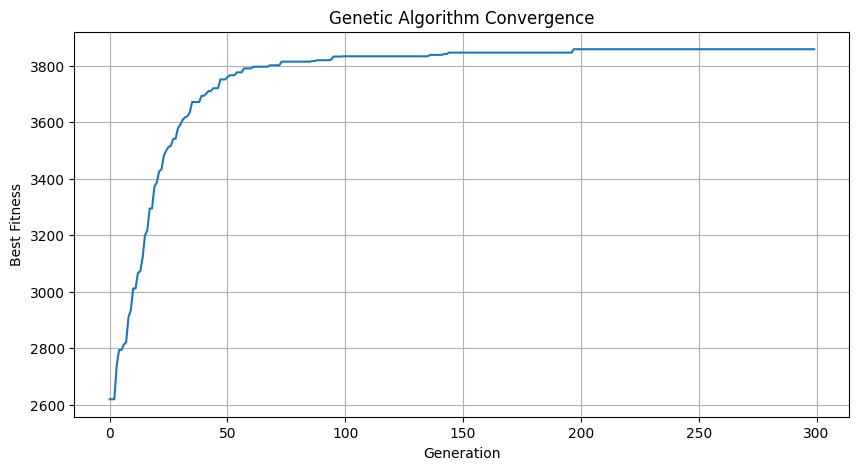

In [26]:
plt.figure(figsize=(10,5))

plt.plot(
    history
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Best Fitness"
)

plt.title(
    "Genetic Algorithm Convergence"
)

plt.grid()

plt.show()

<h3> Step 7.2: Tournament vs Roulette Comparison </h3>

In [27]:
result_tournament = genetic_algorithm(
    problem,
    chromosome_length=100,
    population_size=200,
    generations=300,
    elite_ratio=0.1,
    selection_method="tournament",
    tournament_size=5,
    crossover_rate=0.8,
    crossover_point_ratio=0.5,
    mutation_rate=0.01,
)

fitness_tournament = (
    result_tournament["fitness"]
)

In [28]:
result_roulette = genetic_algorithm(
    problem,
    chromosome_length=100,
    population_size=200,
    generations=300,
    elite_ratio=0.1,
    selection_method="roulette",
    crossover_rate=0.8,
    crossover_point_ratio=0.5,
    mutation_rate=0.01,
)

fitness_roulette = (
    result_roulette["fitness"]
)

In [29]:
print(
    "Tournament:",
    fitness_tournament
)

print(
    "Roulette:",
    fitness_roulette
)

Tournament: 3837
Roulette: 3828


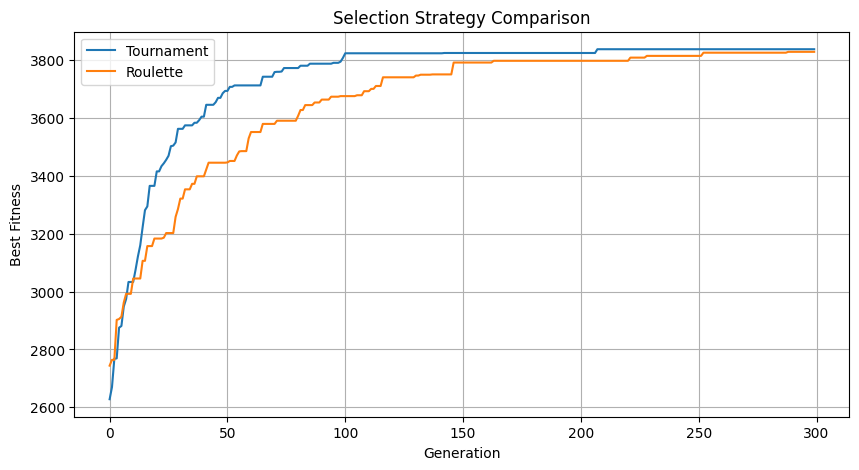

In [30]:
plt.figure(figsize=(10,5))

plt.plot(
    result_tournament["history"],
    label="Tournament"
)

plt.plot(
    result_roulette["history"],
    label="Roulette"
)

plt.xlabel(
    "Generation"
)

plt.ylabel(
    "Best Fitness"
)

plt.title(
    "Selection Strategy Comparison"
)

plt.legend()
plt.grid()
plt.show()

## Selection Strategy Comparison: Tournament vs Roulette Wheel

In this experiment, two parent selection strategies were compared while keeping all other Genetic Algorithm parameters constant.

### Tournament Selection

Tournament selection selects individuals by randomly choosing a subset of the population and selecting the best individual among them.

Advantages:
- Higher selection pressure
- Faster convergence toward promising solutions
- More exploitation of high-quality individuals

However, excessive selection pressure may reduce diversity and increase the risk of premature convergence.

### Roulette Wheel Selection

Roulette wheel selection assigns selection probability proportional to fitness values.

Advantages:
- Maintains more population diversity
- Allows lower-fitness individuals to survive and contribute genetic material
- Provides stronger exploration capability

However, convergence is usually slower because selection pressure is weaker.

### Experimental Observation

The results showed that:

- Tournament selection achieved faster convergence.
- Tournament obtained a slightly better final fitness value, with only a small difference compared to Roulette selection.
- Roulette maintained more diversity due to its probabilistic selection mechanism.

Overall, Tournament selection was more effective for faster optimization in this experiment, while Roulette provided a better exploration-exploitation balance.

<h3> Step 7.3: Parameter Sensitivity Analysis </h3>

We examine three parameters:

1. Mutation Rate </br>
2. Elite Ratio</br>
3. Population Size

<h3> Step 7.3.1: Mutation Ratio </h3>

In [31]:
mutation_results = {}

for rate in [
    0.001,
    0.01,
    0.05,
]:
    result = genetic_algorithm(
        problem,
        chromosome_length=100,
        population_size=200,
        generations=300,
        elite_ratio=0.1,
        selection_method="tournament",
        tournament_size=5,
        crossover_rate=0.8,
        crossover_point_ratio=0.5,
        mutation_rate=rate,
    )

    mutation_results[rate] = result

In [32]:
for rate, result in mutation_results.items():
    print(
        "Mutation:",
        rate,
        "Fitness:",
        result["fitness"]
    )

Mutation: 0.001 Fitness: 3652
Mutation: 0.01 Fitness: 3829
Mutation: 0.05 Fitness: 3797


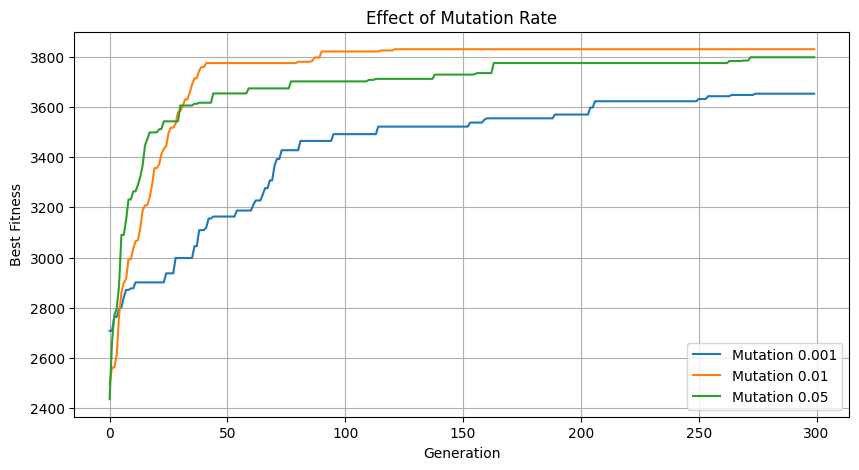

In [33]:
plt.figure(figsize=(10,5))

for rate, result in mutation_results.items():
    plt.plot(
        result["history"],
        label=f"Mutation {rate}"
    )

plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "Effect of Mutation Rate"
)

plt.legend()
plt.grid()
plt.show()

### Effect Of Mutation Ratio

The mutation rate strongly affects the exploration-exploitation trade-off in GA.

- Low mutation (0.001) reduced diversity and caused slower convergence.
- High mutation (0.05) increased exploration but disturbed useful genetic patterns.
- Moderate mutation (0.01) achieved the best final fitness by maintaining a balance between diversity and convergence.

Therefore, selecting an appropriate mutation rate is essential for effective GA performance.

<h3> Step 7.3.2: Elite Ratio </h3>

In [34]:
elite_results = {}

for ratio in [
    0,
    0.05,
    0.1,
    0.2,
]:
    result = genetic_algorithm(
        problem,
        chromosome_length=100,
        population_size=200,
        generations=300,
        elite_ratio=ratio,
        selection_method="tournament",
        tournament_size=5,
        crossover_rate=0.8,
        crossover_point_ratio=0.5,
        mutation_rate=0.01,
    )

    elite_results[ratio] = result

In [35]:
for ratio, result in elite_results.items():
    print(
        "Elite Ratio:",
        ratio,
        "Fitness:",
        result["fitness"]
    )

Elite Ratio: 0 Fitness: 3814
Elite Ratio: 0.05 Fitness: 3849
Elite Ratio: 0.1 Fitness: 3850
Elite Ratio: 0.2 Fitness: 3847


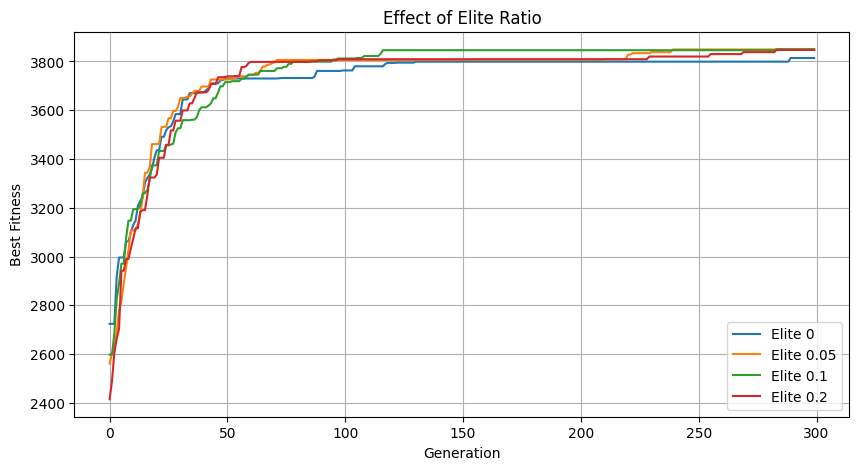

In [36]:
plt.figure(figsize=(10,5))

for ratio, result in elite_results.items():
    plt.plot(
        result["history"],
        label=f"Elite {ratio}"
    )

plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "Effect of Elite Ratio"
)

plt.legend()
plt.grid()
plt.show()

## Effect of Elite Ratio

The effect of different elitism ratios was evaluated by comparing the percentage of preserved best individuals in each generation.

### Observation

- Without elitism (Elite Ratio = 0), the algorithm still converged successfully, but it achieved a slightly lower final fitness because good solutions could be lost during evolution.

- Moderate elitism (Elite Ratio = 0.05 and 0.1) provided a good balance between preserving high-quality solutions and maintaining population diversity. These settings achieved the best convergence behavior.

- Higher elitism (Elite Ratio = 0.2) did not significantly improve the final fitness and may reduce exploration by preserving too many individuals.

### Conclusion

A small amount of elitism improves GA performance by protecting high-quality solutions, while excessive elitism can reduce diversity and limit exploration. In this experiment, an elite ratio around 5–10% provided the best trade-off between exploitation and exploration.

<h3> Step 7.3.3: Population Size </h3>

In [37]:
population_results = {}

for size in [
    50,
    100,
    200,
    500,
]:
    result = genetic_algorithm(
        problem,
        chromosome_length=100,
        population_size=size,
        generations=300,
        elite_ratio=0.1,
        selection_method="tournament",
        tournament_size=5,
        crossover_rate=0.8,
        crossover_point_ratio=0.5,
        mutation_rate=0.01,
    )

    population_results[size] = result

In [38]:
for size, result in population_results.items():
    print(
        "Population:",
        size,
        "Fitness:",
        result["fitness"]
    )

Population: 50 Fitness: 3780
Population: 100 Fitness: 3812
Population: 200 Fitness: 3835
Population: 500 Fitness: 3846


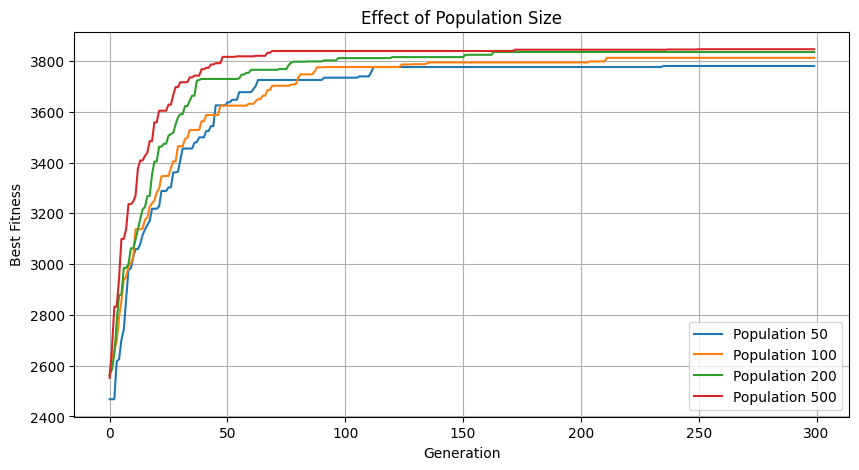

In [39]:
plt.figure(figsize=(10,5))

for size, result in population_results.items():
    plt.plot(
        result["history"],
        label=f"Population {size}"
    )

plt.xlabel(
    "Generation"
)
plt.ylabel(
    "Best Fitness"
)
plt.title(
    "Effect of Population Size"
)

plt.legend()
plt.grid()
plt.show()

## Effect of Population Size

The effect of different population sizes on Genetic Algorithm performance was evaluated by comparing populations of different scales.

### Observation

- A small population size (50) showed slower convergence and achieved a slightly lower final fitness. The limited diversity reduced the ability of GA to explore the search space effectively.

- Increasing the population size improved convergence speed and final solution quality. Larger populations provided more diversity and allowed the algorithm to explore more regions of the search space.

- The largest population size (500) achieved the fastest initial improvement and the highest final fitness. However, this improvement came with increased computational cost.

### Conclusion

Population size has a direct impact on the exploration capability of GA. Larger populations improve diversity and reduce the risk of premature convergence, but they increase computational complexity. In this experiment, a moderate-to-large population size provided a good balance between solution quality and computational cost.